In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# %%
df = pd.read_csv(r"C:\Users\Nese\Desktop\joyRideAI\hourly_transportation_202402.csv")

print("✅ Veri yüklendi")
print(df.columns)
df.head()


✅ Veri yüklendi
Index(['transition_date', 'transition_hour', 'transport_type_id', 'road_type',
       'line', 'transfer_type', 'number_of_passage', 'number_of_passenger'],
      dtype='object')


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger
0,2024-02-01,0,1,OTOYOL,ATESTUGLA - MECIDIYEKOY,Normal,1,1
1,2024-02-01,0,1,OTOYOL,UGURMUMCU-ESENKENT METRO,Normal,2,2
2,2024-02-01,0,3,DENİZ,BESIKTAS-USKUDAR,Normal,1,1
3,2024-02-01,0,1,OTOYOL,SABIHA GOKCEN HAVALIMANI - KADIKOY,Normal,4,4
4,2024-02-01,0,1,OTOYOL,KADIKOY-CAKMAK MAH-ATASEHIR,Aktarma,5,5


In [5]:
# %%
df["timestamp"] = (
    pd.to_datetime(df["transition_date"]) +
    pd.to_timedelta(df["transition_hour"], unit="h")
)

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,hour,timestamp
0,2024-02-01,0,1,OTOYOL,ATESTUGLA - MECIDIYEKOY,Normal,1,1,0,2024-02-01
1,2024-02-01,0,1,OTOYOL,ATESTUGLA - EMINONU,Aktarma,1,1,0,2024-02-01
2,2024-02-01,0,1,OTOYOL,TASOLUK PERONLAR- TEKSTILKENT METRO,Aktarma,2,2,0,2024-02-01
3,2024-02-01,0,1,OTOYOL,BASAKSEHIR 4 -1. ETAPLAR - TAKSIM,Aktarma,1,1,0,2024-02-01
4,2024-02-01,0,1,OTOYOL,KADIKOY-TURKIS BLOKLARI,Normal,3,3,0,2024-02-01


In [6]:
# %%
df["hour"] = df["transition_hour"]
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month


In [7]:
# %%
print(df["line"].value_counts().head(10))


line
YENIKAPI - HACIOSMAN          6756
KADIKOY-KARTAL                6717
YENIKAPI - HAVALIMANI         6602
KABATAS-MAHMUTBEY             6386
KABATAS-BAGCILAR              6353
USKUDAR-CEKMEKOY              6312
TOPKAPI-HABIBLER              6174
ALTUNIZADE-SULTANBEYLI        6055
KADIKOY-SARIGAZI-YENIDOGAN    5862
EMINONU-ALIBEYKOY             5736
Name: count, dtype: int64


In [12]:
# %%
TARGET_LINE = "AVCILAR-ZINCIRLIKUYU"   # istediğin hattı buradan değiştir

route_df = df[df["line"] == TARGET_LINE].copy()

print("Seçilen hat:", TARGET_LINE)
print("Satır sayısı:", len(route_df))


Seçilen hat: AVCILAR-ZINCIRLIKUYU
Satır sayısı: 5367


In [13]:
# %%
route_df.rename(
    columns={"number_of_passenger": "density"},
    inplace=True
)

scaler = MinMaxScaler()
route_df["density"] = scaler.fit_transform(
    route_df[["density"]]
)

route_df[["timestamp", "density"]].head()


,timestamp,density
17,2024-02-01,0.044011
138,2024-02-01,0.000058
222,2024-02-01,0.009100
250,2024-02-01,0.000146
280,2024-02-01,0.000058


In [14]:
# %%
route_df["density_t_plus_1h"] = route_df["density"].shift(-1)
route_df.dropna(inplace=True)

route_df[["density", "density_t_plus_1h"]].head()


,density,density_t_plus_1h
17,0.044011,0.000058
138,0.000058,0.009100
222,0.009100,0.000146
250,0.000146,0.000058
280,0.000058,0.000087


In [15]:
# %%
feature_cols = ["hour", "day_of_week", "month", "density"]
target_col = "density_t_plus_1h"

X = route_df[feature_cols]
y = route_df[target_col]

print(X.shape, y.shape)


(5366, 4) (5366,)


In [16]:
# %%
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [17]:
# %%
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05
    ))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📉 MAE  : {mae:.4f}")
print(f"📊 RMSE : {rmse:.4f}")


📉 MAE  : 0.0749
📊 RMSE : 0.1361


In [19]:
# %%
def best_departure_time(current_row, model, max_wait=3):

    results = []
    base_density = current_row["density"]

    for h in range(max_wait + 1):
        future_hour = (current_row["hour"] + h) % 24

        X_future = [[
            future_hour,
            current_row["day_of_week"],
            current_row["month"],
            base_density
        ]]

        pred_density = model.predict(X_future)[0]

        results.append({
            "wait_hours": h,
            "predicted_density": round(pred_density, 4)
        })

    return pd.DataFrame(results)



In [20]:
# %%
sample_row = route_df.iloc[1000]
decision_df = best_departure_time(sample_row, svm_model)
decision_df


c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,wait_hours,predicted_density
0,0,0.0500
1,1,0.0497
2,2,0.0495
3,3,0.0346


In [21]:
# %%
def minute_level_decision(decision_df, minute_steps=[15, 30, 45]):

    rows = []

    now_density = decision_df.loc[0, "predicted_density"]
    next_density = decision_df.loc[1, "predicted_density"]

    for m in minute_steps:
        ratio = m / 60
        interpolated_density = (
            now_density * (1 - ratio) + next_density * ratio
        )

        rows.append({
            "wait_minutes": m,
            "predicted_density": round(interpolated_density, 4)
        })

    return pd.DataFrame(rows)


minute_df = minute_level_decision(decision_df)
minute_df


,wait_minutes,predicted_density
0,15,0.0499
1,30,0.0499
2,45,0.0498


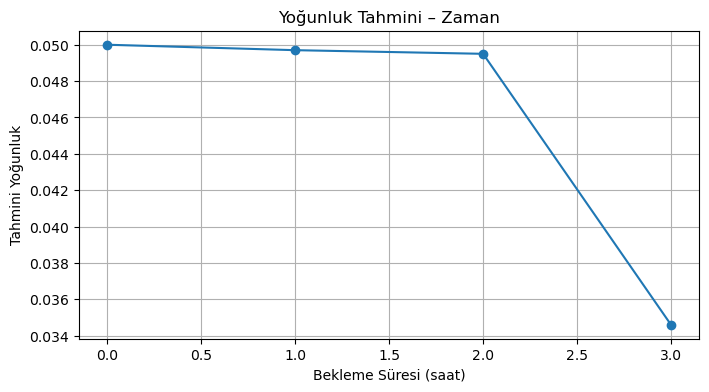

In [22]:
# %%
def plot_density_forecast(decision_df):

    plt.figure(figsize=(8, 4))
    plt.plot(
        decision_df["wait_hours"],
        decision_df["predicted_density"],
        marker="o"
    )

    plt.xlabel("Bekleme Süresi (saat)")
    plt.ylabel("Tahmini Yoğunluk")
    plt.title("Yoğunluk Tahmini – Zaman")
    plt.grid(True)
    plt.show()


plot_density_forecast(decision_df)


In [27]:
q1 = route_df["density"].quantile(0.33)
q2 = route_df["density"].quantile(0.66)

def density_to_class(d):
    if d < q1:
        return "Rahat"
    elif d < q2:
        return "Orta"
    else:
        return "Yogun"


In [28]:
# %%
print(classification_report(
    y_true_cls,
    y_pred_cls,
    digits=3
))


              precision    recall  f1-score   support

        Orta      0.000     0.000     0.000        39
       Rahat      0.952     0.998     0.975      1023
       Yogun      0.000     0.000     0.000        12

    accuracy                          0.951      1074
   macro avg      0.317     0.333     0.325      1074
weighted avg      0.907     0.951     0.928      1074



c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# %%
class_names = ["Rahat", "Orta", "Yogun"]

cm = confusion_matrix(
    y_true_cls,
    y_pred_cls,
    labels=class_names
)

cm_df = pd.DataFrame(
    cm,
    index=["Gerçek_Rahat", "Gerçek_Orta", "Gerçek_Yogun"],
    columns=["Tahmin_Rahat", "Tahmin_Orta", "Tahmin_Yogun"]
)

cm_df


,Tahmin_Rahat,Tahmin_Orta,Tahmin_Yogun
Gerçek_Rahat,1021,2,0
Gerçek_Orta,39,0,0
Gerçek_Yogun,12,0,0


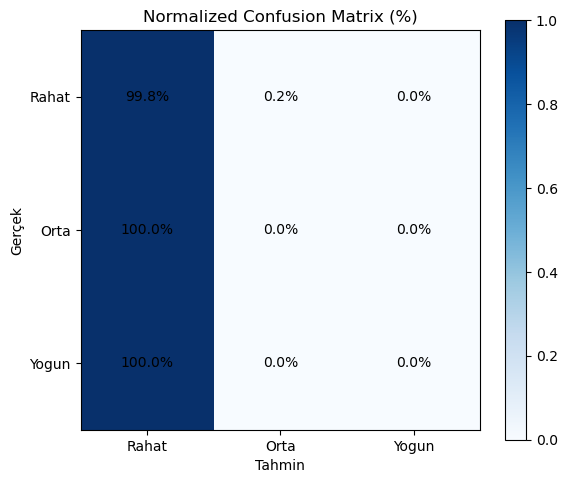

In [31]:
# %%
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues")
plt.title("Normalized Confusion Matrix (%)")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j, i, f"{cm_norm[i, j]*100:.1f}%",
            ha="center", va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()
